# Differentially Private SVM - Kidney Stone Risk Prediction Dataset

**Method**: Objective Perturbation with Huber Loss (Chaudhuri et al. 2011)

Pure ε-DP via spherically symmetric noise ν(b) ∝ exp(−β‖b‖₂) added to the objective.

In [1]:
import time
import os
import sys
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')

# The DP-SVM implementation and the model exporter are shared across all
# datasets and live at the repository root.
REPO_ROOT = os.path.abspath(os.path.join('..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from common_svm import DifferentiallyPrivateSVM  # noqa: E402
from model_exporter import export_model  # noqa: E402

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
with open("../data/processed_data.pkl","rb") as f: loaded_data = pickle.load(f)
X_train=loaded_data["X_train"]; X_test=loaded_data["X_test"]
y_train=loaded_data["y_train"]; y_test=loaded_data["y_test"]

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)
print(f"Training: {X_train.shape} | Test: {X_test.shape}")


Training: (3200, 23) | Test: (800, 23)


In [3]:
try:
    baseline_df=pd.read_csv("output/baseline_results.csv")
    baseline_accuracy=baseline_df["accuracy"].values[0]; baseline_f1=baseline_df["f1_score"].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f} | F1: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_SVM.ipynb first."); baseline_accuracy=None; baseline_f1=None


Baseline Accuracy: 0.9325 | F1: 0.9088


## DP-SVM Implementation (Objective Perturbation)

**Implementation:** `DifferentiallyPrivateSVM` from `common_svm.py` at the repository root — a single shared implementation of Algorithm 2 (Chaudhuri, Monteleoni & Sarwate, JMLR 2011) used by every dataset.

`normalize=True` deterministically projects each record onto the unit L2 ball, x → x / max(1, ‖x‖₂), so the privacy precondition ‖x_i‖₂ ≤ 1 holds. The same record-wise projection is applied at inference.

`fit_intercept=False` fixes the intercept at zero, so every optimized parameter is L2-regularized and the objective satisfies the theorem's strong-convexity setting; noise is drawn in d = n_features dimensions.

`privacy_report()` records ε′, Δ and whether Algorithm 2's fallback branch fired. When it does, the effective budget is ε/2 rather than ε — the sweep below stores this per ε in the JSON report.


In [4]:
# SVM uses {-1,+1} labels
y_train_svm = np.where(y_train==1,1,-1)
N_RUNS=30; epsilon=1.0
detail_accs=[]; detail_f1s=[]
print(f"Training DP-SVM {N_RUNS} times with epsilon={epsilon}...")
detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed=run*10+42
    m=DifferentiallyPrivateSVM(epsilon=epsilon,Lambda=0.01,h=0.5,fit_intercept=False,normalize=True,random_state=seed)
    _t0 = time.perf_counter()
    m.fit(X_train,y_train_svm)
    train_time = time.perf_counter() - _t0
    yp_svm=m.predict(X_test); yp=(yp_svm+1)//2
    detail_accs.append(accuracy_score(y_test,yp)); detail_f1s.append(f1_score(y_test,yp,zero_division=0))
    detail_extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {detail_accs[-1]:.4f} | F1: {detail_f1s[-1]:.4f}")
avg_acc=float(np.mean(detail_accs))
print(f"\nAcc: {avg_acc:.4f}\u00b1{np.std(detail_accs):.4f}")
if baseline_accuracy: print(f"Acc Loss: {baseline_accuracy-avg_acc:.4f} ({(baseline_accuracy-avg_acc)*100:.2f}%)")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP-SVM 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.8900 | F1: 0.8388
  Run  2/30 | Acc: 0.8900 | F1: 0.8388
  Run  3/30 | Acc: 0.8900 | F1: 0.8388
  Run  4/30 | Acc: 0.8900 | F1: 0.8388
  Run  5/30 | Acc: 0.8900 | F1: 0.8388
  Run  6/30 | Acc: 0.8900 | F1: 0.8388
  Run  7/30 | Acc: 0.8900 | F1: 0.8388
  Run  8/30 | Acc: 0.8900 | F1: 0.8388
  Run  9/30 | Acc: 0.8900 | F1: 0.8388
  Run 10/30 | Acc: 0.8900 | F1: 0.8388
  Run 11/30 | Acc: 0.8900 | F1: 0.8388
  Run 12/30 | Acc: 0.8900 | F1: 0.8388
  Run 13/30 | Acc: 0.8900 | F1: 0.8388
  Run 14/30 | Acc: 0.8900 | F1: 0.8388
  Run 15/30 | Acc: 0.8900 | F1: 0.8388
  Run 16/30 | Acc: 0.8900 | F1: 0.8388
  Run 17/30 | Acc: 0.8900 | F1: 0.8388
  Run 18/30 | Acc: 0.8900 | F1: 0.8388
  Run 19/30 | Acc: 0.8900 | F1: 0.8388
  Run 20/30 | Acc: 0.8900 | F1: 0.8388
  Run 21/30 | Acc: 0.8900 | F1: 0.8388
  Run 22/30 | Acc: 0.8900 | F1: 0.8388
  Run 23/30 | Acc: 0.8900 | F1: 0.8388
  Run 24/30 | Acc: 0.8900 | F1: 0.8388
  Run 25/30 | Acc: 

## Full sweep across all ε values

In [5]:
epsilon_values=[0.1,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,4.0,6.0,8.0,10.0]
N_RUNS=30
parameters={"model":"DP-SVM with Huber Loss","Lambda":0.01,"h":0.5,"method":"Objective Perturbation (L2-norm spherical noise, \u03bd(b) \u221d exp(-\u03b2\u2016b\u2016\u2082))","optimizer":"L-BFGS-B","n_runs":N_RUNS}
results_json={"model_type":"DP-SVM (Huber + Objective Perturbation)","dataset":"Kidney Stone Risk Prediction Dataset","n_runs_per_epsilon":N_RUNS,"epsilon_results":{}}
results={"epsilon":[],"accuracy_mean":[],"accuracy_std":[],"f1_score_mean":[],"f1_score_std":[],"precision_mean":[],"precision_std":[],"recall_mean":[],"recall_std":[]}
print(f"Training DP-SVM with {N_RUNS} runs per epsilon value...")
print("="*80)
for eps in epsilon_values:
    run_accs=[]; run_f1s=[]; run_precs=[]; run_recs=[]; run_cms=[]
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed=run*10+42
        m=DifferentiallyPrivateSVM(epsilon=eps,Lambda=0.01,h=0.5,fit_intercept=False,normalize=True,random_state=seed)
        _t0 = time.perf_counter()
        m.fit(X_train,y_train_svm)
        train_time = time.perf_counter() - _t0
        yp_svm=m.predict(X_test); yp=(yp_svm+1)//2
        run_accs.append(accuracy_score(y_test,yp)); run_f1s.append(f1_score(y_test,yp,zero_division=0))
        extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
        run_precs.append(precision_score(y_test,yp,zero_division=0)); run_recs.append(recall_score(y_test,yp,zero_division=0))
        run_cms.append(confusion_matrix(y_test,yp).tolist())
        if run == 0:
            export_model(m, f'output/model/dp_svm_model_eps_{eps}.pkl')
            privacy = m.privacy_report()
    acc_m,acc_s=np.mean(run_accs),np.std(run_accs); f1_m,f1_s=np.mean(run_f1s),np.std(run_f1s)
    prec_m,prec_s=np.mean(run_precs),np.std(run_precs); rec_m,rec_s=np.mean(run_recs),np.std(run_recs)
    results["epsilon"].append(eps); results["accuracy_mean"].append(acc_m); results["accuracy_std"].append(acc_s)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results["f1_score_mean"].append(f1_m); results["f1_score_std"].append(f1_s)
    results["precision_mean"].append(prec_m); results["precision_std"].append(prec_s)
    results["recall_mean"].append(rec_m); results["recall_std"].append(rec_s)
    results_json["epsilon_results"][str(eps)]=dict(epsilon=float(eps),n_runs=N_RUNS,accuracy_mean=acc_m,accuracy_std=acc_s,f1_mean=f1_m,f1_std=f1_s,precision_mean=prec_m,precision_std=prec_s,recall_mean=rec_m,recall_std=rec_s,per_run_accuracies=run_accs,per_run_f1s=run_f1s,per_run_confusion_matrices=run_cms,parameters=parameters.copy(),privacy=privacy)
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
    print(f"\u03b5={eps:5.1f} | Acc: {acc_m:.4f}\u00b1{acc_s:.4f} | F1: {f1_m:.4f}\u00b1{f1_s:.4f} | Prec: {prec_m:.4f}\u00b1{prec_s:.4f} | Rec: {rec_m:.4f}\u00b1{rec_s:.4f}")
    if privacy['fallback_triggered']:
        print(f"        Algorithm 2 fallback fired: effective \u03b5' ="
              f" {privacy['eps_prime']:.4f}, \u0394 = {privacy['Delta']:.6f}")
print("="*80); print("Training complete!")


Training DP-SVM with 30 runs per epsilon value...
Model successfully exported to output/model/dp_svm_model_eps_0.1.pkl
ε=  0.1 | Acc: 0.7423±0.0568 | F1: 0.6658±0.0753 | Prec: 0.6810±0.0841 | Rec: 0.6600±0.0994
Model successfully exported to output/model/dp_svm_model_eps_0.2.pkl
ε=  0.2 | Acc: 0.8808±0.0116 | F1: 0.8294±0.0138 | Prec: 0.9451±0.0379 | Rec: 0.7398±0.0158
Model successfully exported to output/model/dp_svm_model_eps_0.4.pkl
ε=  0.4 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000 | Prec: 0.9828±0.0000 | Rec: 0.7316±0.0000
Model successfully exported to output/model/dp_svm_model_eps_0.6.pkl
ε=  0.6 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000 | Prec: 0.9828±0.0000 | Rec: 0.7316±0.0000
Model successfully exported to output/model/dp_svm_model_eps_0.8.pkl
ε=  0.8 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000 | Prec: 0.9828±0.0000 | Rec: 0.7316±0.0000
Model successfully exported to output/model/dp_svm_model_eps_1.0.pkl
ε=  1.0 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000 | Prec: 0.9828±0.0000 | Rec

In [6]:
os.makedirs("output",exist_ok=True)
with open("output/dp_svm_report.json","w") as f: json.dump(results_json,f,indent=4)
results_df=pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df["accuracy_loss_mean"]=baseline_accuracy-results_df["accuracy_mean"]
    results_df["accuracy_loss_pct"]=results_df["accuracy_loss_mean"]*100
results_df.to_csv("output/dp_results.csv",index=False)
print("Results saved to output/"); print(results_df.to_string(index=False))


Results saved to output/
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean   recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1        0.74225  5.676101e-02       0.665755  7.533463e-02        0.681047   8.414890e-02     0.659957 9.942447e-02                0.727549           5.849029e-02      0.790381     0.058993         0.001127        0.000136             0.19025             19.025
     0.2        0.88075  1.155873e-02       0.829364  1.382492e-02        0.945065   3.787947e-02     0.739830 1.577475e-02                0.855575           9.916645e-03      0.886776     0.027530         0.001769        0.000151             0.05175              5.175
     0.4        0.89000  1.110223e-16       0.838828  1.110223e-16        0.982833   2.220446e-16     0.731629 1.110223e-16                0.861708           3.33066

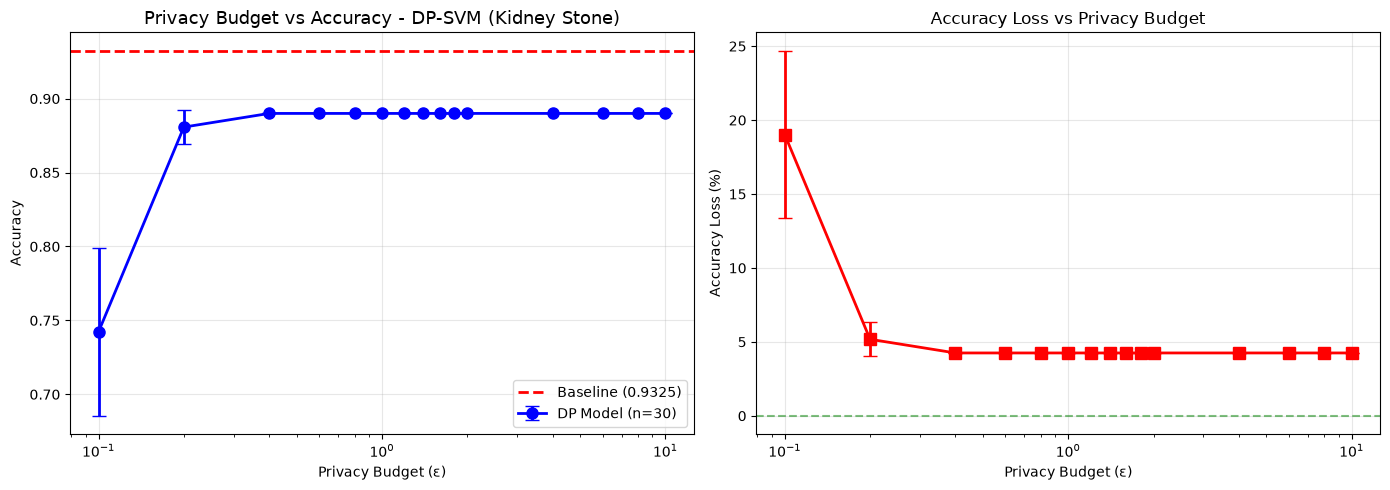

Plot saved.


In [7]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].errorbar(results_df["epsilon"],results_df["accuracy_mean"],yerr=results_df["accuracy_std"],fmt="bo-",linewidth=2,markersize=8,capsize=5,label=f"DP Model (n={N_RUNS})")
if baseline_accuracy: axes[0].axhline(y=baseline_accuracy,color="r",linestyle="--",linewidth=2,label=f"Baseline ({baseline_accuracy:.4f})")
axes[0].set_title("Privacy Budget vs Accuracy - DP-SVM (Kidney Stone)",fontsize=13)
axes[0].set_xlabel("Privacy Budget (\u03b5)"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_xscale("log")
if baseline_accuracy:
    axes[1].errorbar(results_df["epsilon"],results_df["accuracy_loss_pct"],yerr=results_df["accuracy_std"]*100,fmt="rs-",linewidth=2,markersize=8,capsize=5)
    axes[1].set_title("Accuracy Loss vs Privacy Budget"); axes[1].set_xlabel("Privacy Budget (\u03b5)"); axes[1].set_ylabel("Accuracy Loss (%)")
    axes[1].grid(True,alpha=0.3); axes[1].set_xscale("log"); axes[1].axhline(y=0,color="g",linestyle="--",alpha=0.5)
plt.tight_layout(); plt.savefig("output/privacy_accuracy_tradeoff.png",dpi=150,bbox_inches="tight")
plt.show(); print("Plot saved.")


In [8]:
print("\n"+"="*60)
print("IMPLEMENTATION DETAILS")
print("="*60)
print("Method: Objective Perturbation with Huber Loss")
print("Privacy Mechanism: spherical noise \u03bd(b) \u221d exp(-\u03b2\u2016b\u2016\u2082) (Pure \u03b5-DP)")
print(f"Regularization (\u039b): {parameters['Lambda']}")
print(f"Huber h: {parameters['h']}")
print(f"Second derivative bound c = 1/(2h) = {1.0/(2.0*parameters['h']):.4f}")
print("Optimization: L-BFGS-B"); print(f"N_RUNS per epsilon: {N_RUNS}")
print("Reference: Chaudhuri et al. (2011)")
print("="*60)



IMPLEMENTATION DETAILS
Method: Objective Perturbation with Huber Loss
Privacy Mechanism: spherical noise ν(b) ∝ exp(-β‖b‖₂) (Pure ε-DP)
Regularization (Λ): 0.01
Huber h: 0.5
Second derivative bound c = 1/(2h) = 1.0000
Optimization: L-BFGS-B
N_RUNS per epsilon: 30
Reference: Chaudhuri et al. (2011)
